In [3]:
# ============================================================
# STUDENT PLACEMENT PREDICTOR
# PHASE 3 - RANDOM FOREST
# ============================================================

print("Phase 3 - Random Forest Classifier")

Phase 3 - Random Forest Classifier


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

In [4]:
import requests
from io import BytesIO

DATA_URL = "https://raw.githubusercontent.com/Aarya7306/STUDENT_PLACEMENT_PREDICTOR/main/student_placement_phase1_ready.xlsx"

response = requests.get(DATA_URL)
response.raise_for_status()

df = pd.read_excel(
    BytesIO(response.content)
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (100000, 20)


,college_pursuing_year,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,placement_status
0,4,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,72.647009,77.463863,2,63.382726,52.938240,Yes,Not Placed
1,4,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,61.699110,88.887600,1,73.694605,60.198856,No,Not Placed
2,4,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,87.396911,74.153265,0,63.329294,43.708803,No,Placed
3,4,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,58.401069,87.635955,1,47.636099,56.549154,Yes,Not Placed
4,3,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,74.489201,79.120749,1,0.000000,67.268893,No,Placed


In [5]:
print(df.columns.tolist())

['college_pursuing_year', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'placement_status']


In [6]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (100000, 20)

Missing values:
college_pursuing_year        0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
placement_status             0
dtype: int64

Duplicate rows: 0

Data types:
college_pursuing_year          int64
cgpa                         float64
branch                        object
college_tier                  object
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
ap

In [7]:
# ============================================================
# CELL 6 - CHECK TARGET
# ============================================================

TARGET = "placement_status"

print("Target column:", TARGET)
print("\nTarget values:")
print(df[TARGET].value_counts())

print("\nUnique target values:")
print(df[TARGET].unique())

Target column: placement_status

Target values:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

Unique target values:
['Not Placed' 'Placed']


In [8]:
# ============================================================
# CELL 7 - DEFINE FEATURES AND TARGET
# ============================================================

FEATURES = [
    "college_pursuing_year",
    "cgpa",
    "branch",
    "college_tier",
    "internships_count",
    "projects_count",
    "certifications_count",
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "hackathons_participated",
    "github_repos",
    "mock_interview_score",
    "attendance_percentage",
    "backlogs",
    "extracurricular_score",
    "leadership_score",
    "volunteer_experience"
]

TARGET = "placement_status"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Number of features:", len(FEATURES))
print("\nFeatures:")
for feature in FEATURES:
    print("-", feature)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of features: 19

Features:
- college_pursuing_year
- cgpa
- branch
- college_tier
- internships_count
- projects_count
- certifications_count
- coding_skill_score
- aptitude_score
- communication_skill_score
- logical_reasoning_score
- hackathons_participated
- github_repos
- mock_interview_score
- attendance_percentage
- backlogs
- extracurricular_score
- leadership_score
- volunteer_experience

X shape: (100000, 19)
y shape: (100000,)


In [9]:
# ============================================================
# CELL 8 - ENCODE TARGET
# ============================================================

if y.dtype == "object":

    y = (
        y.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "placed": 1,
            "not placed": 0,
            "not_placed": 0,
            "notplaced": 0
        })
    )

print("Encoded target values:")
print(y.value_counts())

print("\nUnique encoded values:")
print(y.unique())

Encoded target values:
placement_status
1    54459
0    45541
Name: count, dtype: int64

Unique encoded values:
[0 1]


In [10]:
# ============================================================
# CELL 9 - CHECK MISSING VALUES
# ============================================================

missing = X.isnull().sum()

print("Missing values in selected features:")
print(missing[missing > 0])

print("\nTotal missing values:", missing.sum())

Missing values in selected features:
Series([], dtype: int64)

Total missing values: 0


In [15]:
# ============================================================
# CELL 10 - DEFINE NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numerical_features = [
    "college_pursuing_year",
    "cgpa",
    "internships_count",
    "projects_count",
    "certifications_count",
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "hackathons_participated",
    "github_repos",
    "mock_interview_score",
    "attendance_percentage",
    "backlogs",
    "extracurricular_score",
    "leadership_score"
]

categorical_features = [
    "branch",
    "college_tier",
    "volunteer_experience"
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical columns:")
for col in categorical_features:
    print(f"- {col}")

Numerical features: 16
Categorical features: 3

Categorical columns:
- branch
- college_tier
- volunteer_experience


In [16]:
# ============================================================
# CELL 11 - TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (80000, 19)
Testing data: (20000, 19)

Training target distribution:
placement_status
1    0.544588
0    0.455412
Name: proportion, dtype: float64

Testing target distribution:
placement_status
1    0.5446
0    0.4554
Name: proportion, dtype: float64


In [17]:
# ============================================================
# CELL 12 - PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (80000, 27)
Testing data shape: (20000, 27)


In [18]:
# ============================================================
# CELL 13 - PROCESSED FEATURE NAMES
# ============================================================

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed features:")
for feature in feature_names:
    print(feature)

Number of processed features: 27

Processed features:
num__college_pursuing_year
num__cgpa
num__internships_count
num__projects_count
num__certifications_count
num__coding_skill_score
num__aptitude_score
num__communication_skill_score
num__logical_reasoning_score
num__hackathons_participated
num__github_repos
num__mock_interview_score
num__attendance_percentage
num__backlogs
num__extracurricular_score
num__leadership_score
cat__branch_CSE
cat__branch_Civil
cat__branch_ECE
cat__branch_EEE
cat__branch_IT
cat__branch_Mechanical
cat__college_tier_Tier 1
cat__college_tier_Tier 2
cat__college_tier_Tier 3
cat__volunteer_experience_No
cat__volunteer_experience_Yes


In [19]:
# ============================================================
# CELL 14 - RANDOM FOREST MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [20]:
# ============================================================
# CELL 15 - PREDICTIONS
# ============================================================

y_pred = rf_model.predict(X_test_processed)

y_prob = rf_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated.")

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 placement probabilities:")
print(y_prob[:10])

Predictions generated.

First 10 predictions:
[0 0 1 0 0 0 1 1 1 1]

First 10 placement probabilities:
[0.43 0.47 0.52 0.45 0.41 0.48 0.58 0.57 0.53 0.54]


In [21]:
# ============================================================
# CELL 16 - MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("======================================")
print("RANDOM FOREST PERFORMANCE")
print("======================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy  : 0.5507
Precision : 0.5706
Recall    : 0.7074
F1 Score  : 0.6317
ROC-AUC   : 0.5588


In [22]:
# ============================================================
# CELL 17 - CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Placed",
            "Placed"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Not Placed       0.51      0.36      0.42      9108
      Placed       0.57      0.71      0.63     10892

    accuracy                           0.55     20000
   macro avg       0.54      0.54      0.53     20000
weighted avg       0.54      0.55      0.54     20000



Confusion Matrix:
[[3309 5799]
 [3187 7705]]


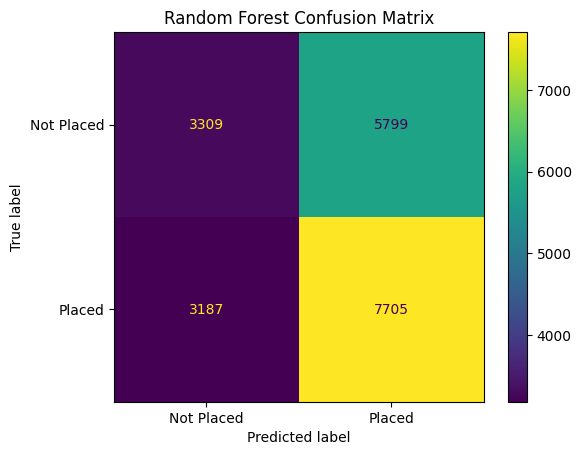

In [23]:
# ============================================================
# CELL 18 - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Placed",
        "Placed"
    ]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

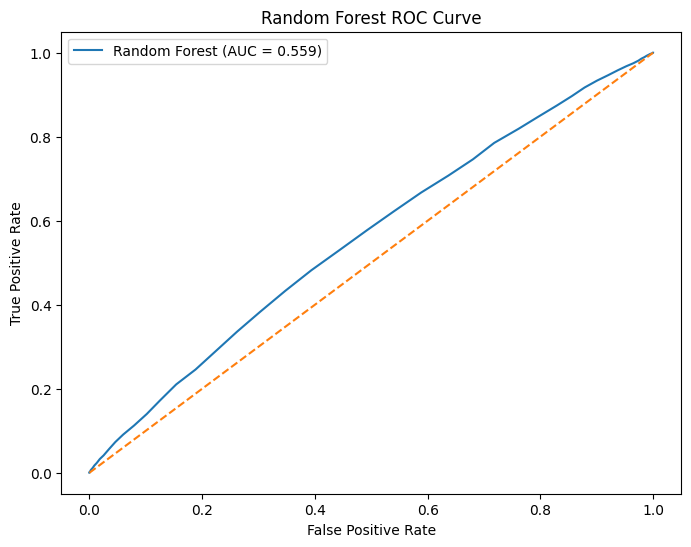

In [24]:
# ============================================================
# CELL 19 - ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

In [25]:
# ============================================================
# CELL 20 - FEATURE IMPORTANCE
# ============================================================

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance_df.head(20)
)

,feature,importance
0,num__mock_interview_score,0.081332
1,num__coding_skill_score,0.080350
2,num__logical_reasoning_score,0.080178
3,num__aptitude_score,0.080165
4,num__communication_skill_score,0.079833
5,num__leadership_score,0.078904
6,num__extracurricular_score,0.078442
7,num__cgpa,0.076773
8,num__attendance_percentage,0.076038
9,num__github_repos,0.041930


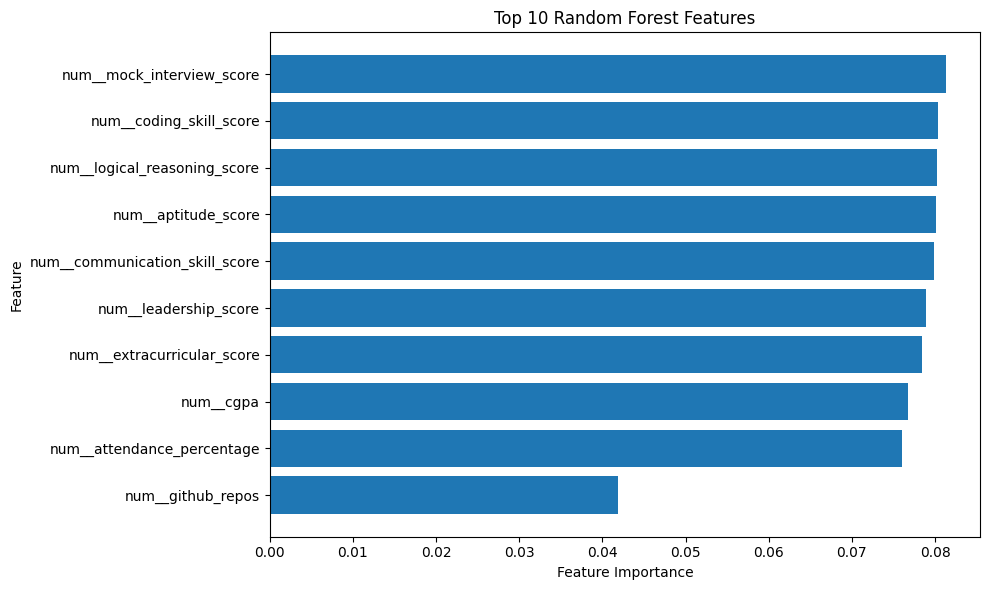

In [26]:
# ============================================================
# CELL 21 - TOP 10 FEATURE IMPORTANCE
# ============================================================

top_10 = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["feature"][::-1],
    top_10["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# CELL 22 - SAVE MODEL METRICS
# ============================================================

metrics_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

display(metrics_df)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest,0.5507,0.570572,0.7074,0.631661,0.558848


In [28]:
# ============================================================
# CELL 23 - SAVE FEATURE IMPORTANCE
# ============================================================

feature_importance_df.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

metrics_df.to_csv(
    "random_forest_metrics.csv",
    index=False
)

print("CSV files created successfully.")

CSV files created successfully.


In [29]:
# ============================================================
# CELL 24 - DOWNLOAD RESULTS
# ============================================================

from google.colab import files

files.download(
    "random_forest_metrics.csv"
)

files.download(
    "random_forest_feature_importance.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
# ============================================================
# CELL 25 - SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

print("Random Forest model saved.")

Random Forest model saved.


In [31]:
# ============================================================
# CELL 26 - FINAL SUMMARY
# ============================================================

print("======================================")
print("PHASE 3 - RANDOM FOREST COMPLETED")
print("======================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nTop 10 Features:")
display(
    feature_importance_df.head(10)
)

PHASE 3 - RANDOM FOREST COMPLETED
Accuracy  : 0.5507
Precision : 0.5706
Recall    : 0.7074
F1 Score  : 0.6317
ROC-AUC   : 0.5588

Top 10 Features:


,feature,importance
0,num__mock_interview_score,0.081332
1,num__coding_skill_score,0.080350
2,num__logical_reasoning_score,0.080178
3,num__aptitude_score,0.080165
4,num__communication_skill_score,0.079833
5,num__leadership_score,0.078904
6,num__extracurricular_score,0.078442
7,num__cgpa,0.076773
8,num__attendance_percentage,0.076038
9,num__github_repos,0.041930
